In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

caminho_arquivo = Path("data/raw/genz_mental_wellness_synthetic_dataset.csv")
df = pd.read_csv(caminho_arquivo)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: './projeto_MLOps/data/raw/genz_mental_wellness_synthetic_dataset.csv'

In [15]:
print("Shape:", df.shape)

Shape: (10000, 22)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  object 
 2   Country                      10000 non-null  object 
 3   Student_Working_Status       10000 non-null  object 
 4   Daily_Social_Media_Hours     10000 non-null  float64
 5   Screen_Time_Hours            10000 non-null  float64
 6   Night_Scrolling_Frequency    10000 non-null  float64
 7   Online_Gaming_Hours          10000 non-null  float64
 8   Content_Type_Preference      10000 non-null  object 
 9   Exercise_Frequency_per_Week  10000 non-null  float64
 10  Daily_Sleep_Hours            10000 non-null  float64
 11  Caffeine_Intake_Cups         10000 non-null  float64
 12  Study_Work_Hours_per_Day     10000 non-null  float64
 13  Overthinking_Scor

In [10]:
df.isnull().sum()

Age                            0
Gender                         0
Country                        0
Student_Working_Status         0
Daily_Social_Media_Hours       0
Screen_Time_Hours              0
Night_Scrolling_Frequency      0
Online_Gaming_Hours            0
Content_Type_Preference        0
Exercise_Frequency_per_Week    0
Daily_Sleep_Hours              0
Caffeine_Intake_Cups           0
Study_Work_Hours_per_Day       0
Overthinking_Score             0
Anxiety_Score                  0
Mood_Stability_Score           0
Social_Comparison_Index        0
Sleep_Quality_Score            0
Motivation_Level               0
Emotional_Fatigue_Score        0
Wellbeing_Index                0
Burnout_Risk                   0
dtype: int64

In [11]:
df.describe()

,Age,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.992900,4.005883,7.016991,2.986009,1.607241,2.994855,6.512031,1.505871,6.030983,5.001868,4.747556,5.161021,4.403556,6.514447,5.086132,5.582222,3.870213
std,2.589309,1.480509,1.792529,1.197035,1.300045,1.478248,1.194194,0.934069,1.975337,1.143179,1.305593,1.257055,1.336479,1.427806,1.308351,1.416558,1.238940
min,18.000000,0.500000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.020000,1.000000,1.000000,1.000000
25%,20.000000,3.010000,5.810000,2.187500,0.470000,1.960000,5.710000,0.800000,4.700000,4.240000,3.840000,4.310000,3.470000,5.550000,4.200000,4.620000,3.020000
50%,22.000000,3.990000,7.000000,2.980000,1.460000,3.010000,6.520000,1.480000,6.030000,5.000000,4.740000,5.170000,4.400000,6.530000,5.080000,5.580000,3.870000
75%,24.000000,4.982500,8.210000,3.790000,2.500000,4.000000,7.320000,2.150000,7.340000,5.760000,5.630000,6.000000,5.320000,7.490000,5.950000,6.540000,4.700000
max,26.000000,10.000000,14.000000,7.000000,6.000000,7.000000,10.000000,6.000000,13.050000,9.510000,9.690000,10.000000,9.420000,10.000000,10.000000,10.000000,8.860000


In [13]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Colunas numéricas:")
print(list(num_cols))

print("\nColunas categóricas:")
print(list(cat_cols))

Colunas numéricas:
['Age', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score', 'Wellbeing_Index']

Colunas categóricas:
['Gender', 'Country', 'Student_Working_Status', 'Content_Type_Preference', 'Burnout_Risk']


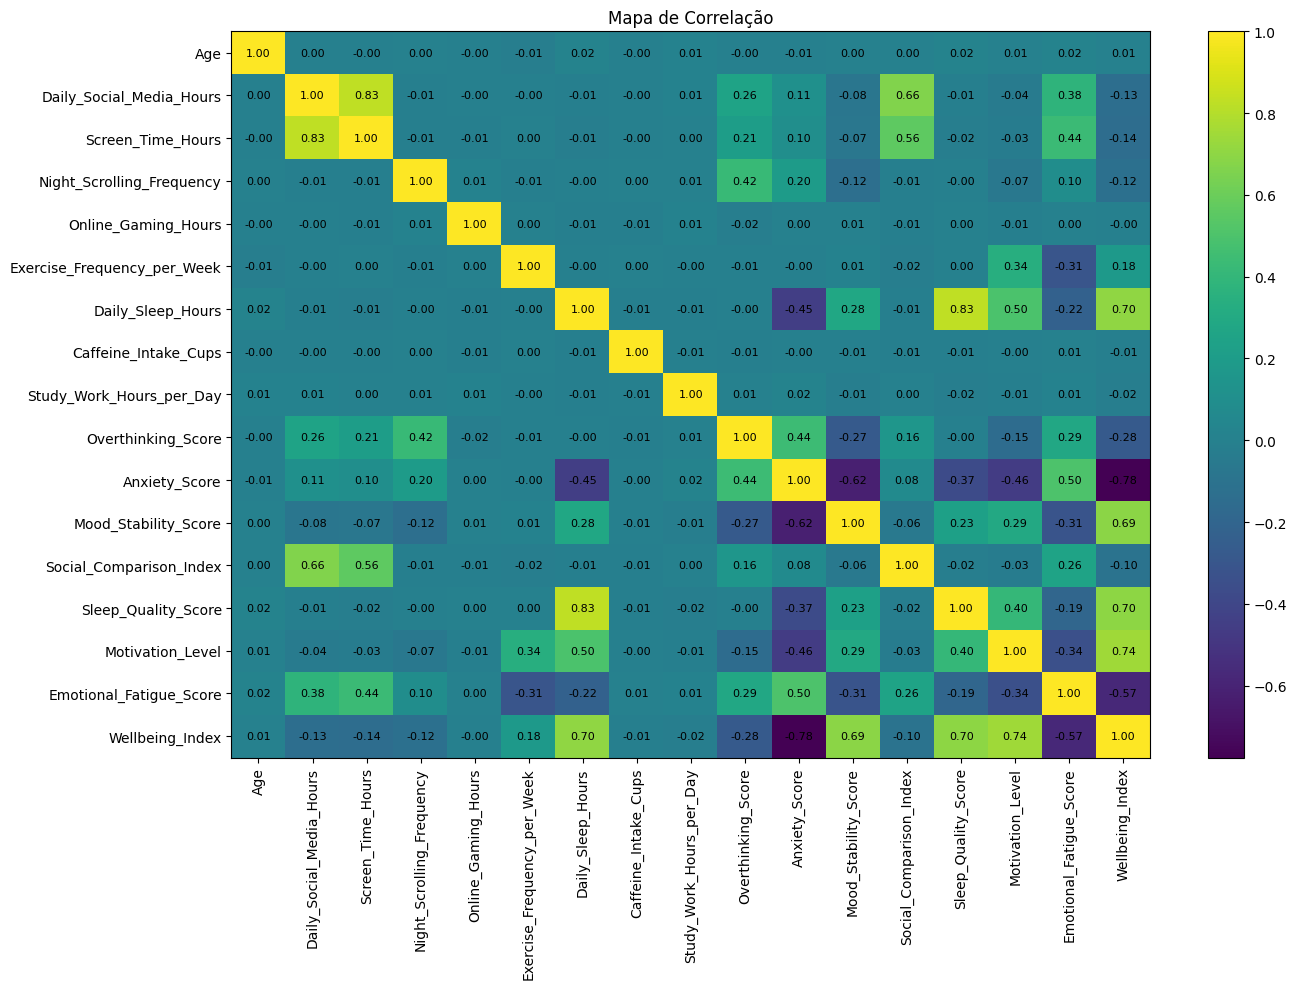

In [16]:
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
im = plt.imshow(corr, aspect='auto')
plt.colorbar(im)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Mapa de Correlação")
plt.tight_layout()
plt.show()

In [ ]:
corr_abs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))

top_corr = (
    corr_abs.stack()
    .sort_values(ascending=False)
    .reset_index()
)

top_corr.columns = ["Variavel_1", "Variavel_2", "Correlacao_Absoluta"]

top_corr.head(10)

,Variavel_1,Variavel_2,Correlacao_Absoluta
0,Daily_Social_Media_Hours,Screen_Time_Hours,0.828104
1,Screen_Time_Hours,Daily_Social_Media_Hours,0.828104
2,Sleep_Quality_Score,Daily_Sleep_Hours,0.827541
3,Daily_Sleep_Hours,Sleep_Quality_Score,0.827541
4,Anxiety_Score,Wellbeing_Index,0.775875
5,Wellbeing_Index,Anxiety_Score,0.775875
6,Wellbeing_Index,Motivation_Level,0.744737
7,Motivation_Level,Wellbeing_Index,0.744737
8,Wellbeing_Index,Daily_Sleep_Hours,0.701866
9,Daily_Sleep_Hours,Wellbeing_Index,0.701866


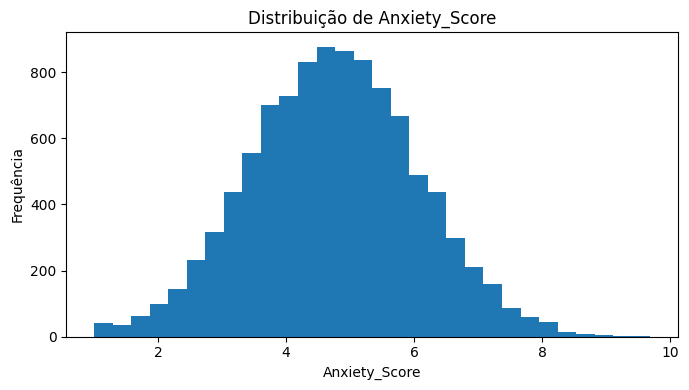

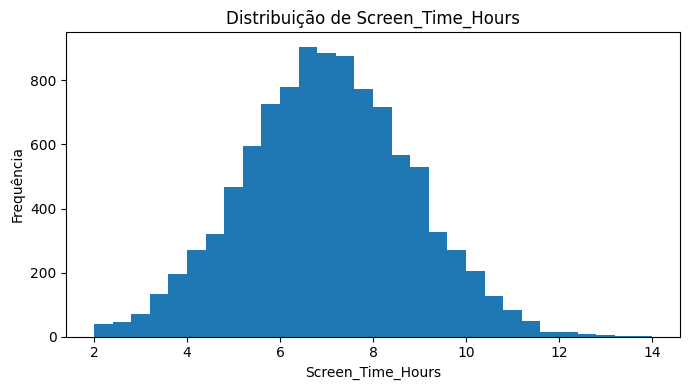

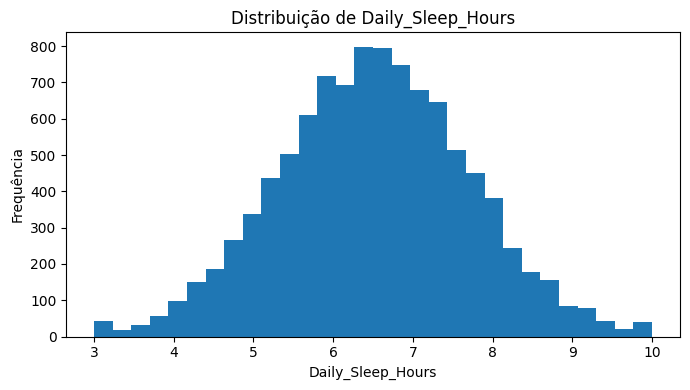

In [18]:
colunas_hist = [
    "Anxiety_Score",
    "Depression_Score",
    "Screen_Time_Hours",
    "Daily_Sleep_Hours"
]

for col in colunas_hist:
    if col in df.columns:
        plt.figure(figsize=(7,4))
        plt.hist(df[col], bins=30)
        plt.title(f"Distribuição de {col}")
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.tight_layout()
        plt.show()

In [19]:
colunas_cat = ["Gender", "Country"]

for col in colunas_cat:
    if col in df.columns:
        print(f"\nFrequência de {col}:")
        print(df[col].value_counts())


Frequência de Gender:
Gender
Male          4547
Female        4481
Non-binary     972
Name: count, dtype: int64

Frequência de Country:
Country
Pakistan     1804
Australia    1693
Canada       1664
USA          1617
India        1616
UK           1606
Name: count, dtype: int64
